In [1]:
%pip install -q tqdm torchmetrics optuna pandas requests
%matplotlib inline

import sys
import pickle
import os
import random
from pathlib import Path
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms as T
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import optuna
import pandas as pd

# Using absolute paths to avoid issues with different working directories
if "__file__" in globals():
    FILE_DIR = Path(__file__).resolve().parent
else:
    # Jupyter notebooks do not have __file__; assume we are in the notebook's directory
    FILE_DIR = Path.cwd()

PROJECT_ROOT = FILE_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from artbench_local_dataset import load_kaggle_artbench10_splits

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


reproducibility and device selection

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(42)
device = get_device()
print('Device:', device)

Device: cuda


In [3]:
def build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
    data_root='data',
    num_workers=0,
):
    dataset_name = dataset_name.lower()

    if dataset_name == 'mnist':
        channels = 1
        image_size = 32
        transform = T.Compose([
            T.Resize((32, 32)),
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(data_root, train=False, download=True, transform=transform)
        class_names = [str(i) for i in range(10)]
    elif dataset_name in ('cifar', 'cifar10'):
        channels = 3
        image_size = 32
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        train_ds = datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        class_names = train_ds.classes
    elif dataset_name == 'artbench':
        channels = 3
        image_size = 32
        transform = T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        
        hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
        train_ds = HFDatasetTorch(hf_ds["train"], transform=transform)
        test_ds = HFDatasetTorch(hf_ds["test"], transform=transform)
        class_names = hf_ds["train"].features["label"].names
    else:
        raise ValueError("dataset_name must be 'mnist', 'cifar10' or 'artbench'.")

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, channels, image_size, class_names

In [4]:
def denorm(x):
    return (x + 1.0) / 2.0


@torch.no_grad()
def evaluate_metrics(generator, dataloader, latent_dim, device, num_samples=5000):
    """
    Evaluates FID and KID metrics for the generator.
    """
    is_training = generator.training
    generator.eval()
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=100, subsets=50, normalize=True).to(device)

    real_count = 0
    for real_imgs, _ in dataloader:
        if real_count >= num_samples:
            break
        batch_size = real_imgs.size(0)
        if real_count + batch_size > num_samples:
            real_imgs = real_imgs[:num_samples - real_count]
            batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_imgs_01 = ((real_imgs + 1.0) / 2.0).clamp(0, 1)
        fid.update(real_imgs_01, real=True)
        kid.update(real_imgs_01, real=True)
        real_count += batch_size

    fake_count = 0
    gen_batch = 100
    while fake_count < num_samples:
        current_batch_size = min(gen_batch, num_samples - fake_count)
        z = torch.randn(current_batch_size, latent_dim, device=device)
        fake_imgs = generator(z)
        fake_imgs_01 = ((fake_imgs + 1.0) / 2.0).clamp(0, 1)
        fid.update(fake_imgs_01, real=False)
        kid.update(fake_imgs_01, real=False)
        fake_count += current_batch_size

    fid_score = fid.compute().item()
    kid_mean, kid_std = kid.compute()
    fid.reset()
    kid.reset()
    if is_training:
        generator.train()
    return fid_score, kid_mean.item(), kid_std.item()


def show_image_grid(images, channels, title='Images', n_show=25, save_path=None):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [5]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        # Slides: "BatchNorm in G, LayerNorm or none in D" — removed BN, kept spectral norm
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size, feature_maps=64):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
                'feature_maps': feature_maps,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    ngf = cfg.get('feature_maps', 64)
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels'], ngf=ngf).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)



In [6]:
def train_gan(
    generator,
    discriminator,
    loader,
    latent_dim,
    epochs=20,
    lr_g=2e-4,
    lr_d=4e-4,
    d_steps=2,
    beta1=0.0,
    beta2=0.99,
    print_progress=True,
    val_loader=None,
    checkpoint_dir=None,
    save_interval=10,
    num_fid_samples=1500
):
    """
    Trains a GAN with monitoring for visual samples and FID metrics.
    """
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))

    history = {'g_loss': [], 'd_loss': [], 'fid': []}
    generator.train()
    discriminator.train()
    
    best_fid = float('inf')
    
    if checkpoint_dir:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        (checkpoint_dir / 'samples').mkdir(exist_ok=True)

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = real.to(device)
            bs = real.size(0)

            # --- Discriminator update (hinge loss) ---
            d_loss = None
            for _ in range(d_steps):
                opt_d.zero_grad(set_to_none=True)
                d_real = discriminator(real)
                d_loss_real = torch.mean(F.relu(1.0 - d_real))

                noise = torch.randn(bs, latent_dim, device=device)
                fake = generator(noise)
                d_fake = discriminator(fake.detach())
                d_loss_fake = torch.mean(F.relu(1.0 + d_fake))

                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                opt_d.step()

            # --- Generator update (hinge loss) ---
            opt_g.zero_grad(set_to_none=True)
            noise = torch.randn(bs, latent_dim, device=device)
            fake = generator(noise)
            g_fake = discriminator(fake)
            g_loss = -torch.mean(g_fake)
            g_loss.backward()
            opt_g.step()

            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1
            
        epoch_g_loss = g_running / max(n_batches, 1)
        epoch_d_loss = d_running / max(n_batches, 1)

        history['g_loss'].append(epoch_g_loss)
        history['d_loss'].append(epoch_d_loss)

        status_str = f"Epoch {epoch + 1:02d}/{epochs} | D loss: {epoch_d_loss:.4f} | G loss: {epoch_g_loss:.4f}"

        # Periodic Monitoring: Visual Samples, FID, and Checkpoints
        if (epoch + 1) % save_interval == 0 or epoch == 0 or epoch == epochs - 1:
            # 1. Visual Samples
            if checkpoint_dir:
                with torch.no_grad():
                    generator.eval()
                    sample_noise = torch.randn(25, latent_dim, device=device)
                    samples = generator(sample_noise)
                    sample_path = checkpoint_dir / 'samples' / f'epoch_{epoch+1:03d}.png'
                    show_image_grid(samples, channels=generator.net[-2].out_channels if hasattr(generator.net[-2], 'out_channels') else 3, 
                                   title=f'Epoch {epoch+1}', save_path=sample_path)
                    generator.train()

            # 2. FID Metrics
            if val_loader:
                fid_score, kid_mean, _ = evaluate_metrics(generator, val_loader, latent_dim, device, num_samples=num_fid_samples)
                history['fid'].append({'epoch': epoch + 1, 'fid': fid_score, 'kid': kid_mean})
                status_str += f" | FID: {fid_score:.2f}"
                
                # Save best model based on FID
                if fid_score < best_fid and checkpoint_dir:
                    best_fid = fid_score
                    save_checkpoint(
                        generator, discriminator, history, 
                        checkpoint_dir / 'best_fid_model.pt', 
                        latent_dim, channels=3, image_size=32 # Defaults
                    )
                    if print_progress:
                        print(f"   -> New best FID: {best_fid:.4f}. Saved best_fid_model.pt")

            # 3. Regular Checkpoint
            if checkpoint_dir:
                save_checkpoint(
                    generator, discriminator, history, 
                    checkpoint_dir / f'checkpoint_epoch_{epoch+1:03d}.pt', 
                    latent_dim, channels=3, image_size=32
                )

        if print_progress:
            print(status_str)

    return history, best_fid



Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


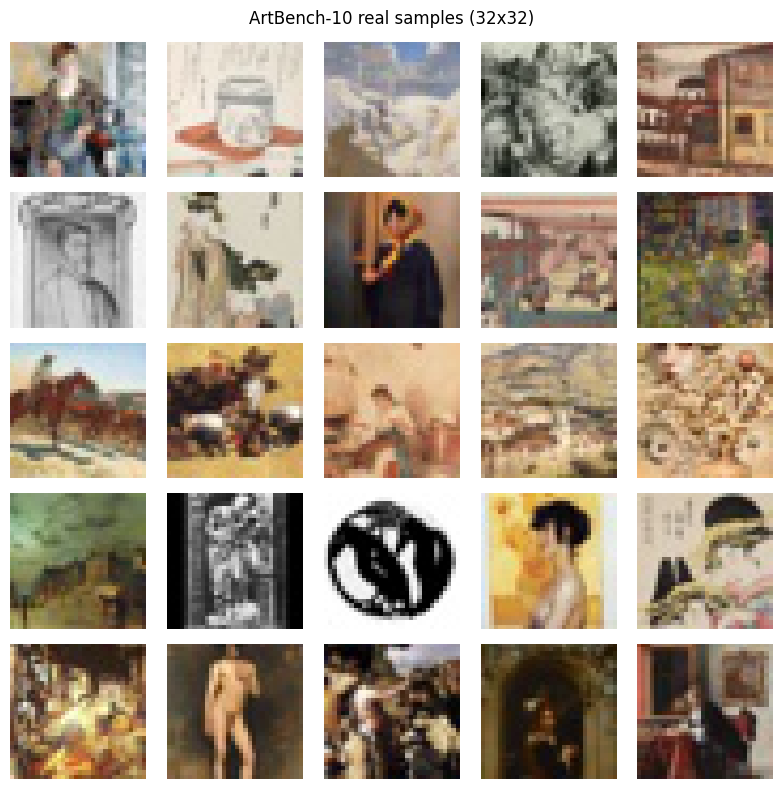

In [7]:
artbench_train_loader, artbench_test_loader, artbench_channels, artbench_image_size, artbench_classes = build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=10000, # 20% of the training data for development
    test_limit=None, # Use all test data for evaluation
    data_root='IAGdata/artbench-10-python',
)

x_artbench, _ = next(iter(artbench_train_loader))
show_image_grid(x_artbench, channels=artbench_channels, title='ArtBench-10 real samples (32x32)', n_show=25)

In [8]:
"""# TODO START
artbench_latent_dim = 100
artbench_epochs = 50 # Increased epochs for better results on ArtBench
artbench_lr = 2e-4
artbench_ckpt = Path('runs/dcgan/artbench_dcgan.pt')

artbench_generator = DCGenerator(latent_dim=artbench_latent_dim, image_channels=artbench_channels).to(device)
artbench_discriminator = DCDiscriminator(image_channels=artbench_channels).to(device)
# TODO END

if artbench_generator is None or artbench_discriminator is None:
    raise NotImplementedError('Instantiate ArtBench DCGAN models inside TODO block.')

# TODO START
# Recommended: initialize DCGAN weights
artbench_generator.apply(init_dcgan_weights)
artbench_discriminator.apply(init_dcgan_weights)
# TODO END

artbench_history, _ = train_gan(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    loader=artbench_train_loader,
    latent_dim=artbench_latent_dim,
    epochs=artbench_epochs,
    lr_g=artbench_lr,
    lr_d=artbench_lr * 2,
    print_progress=True,
    val_loader=artbench_test_loader,
    checkpoint_dir='runs/dcgan/dev_run',
    save_interval=10
)

plot_gan_losses(artbench_history, title='ArtBench-10 DCGAN losses')

save_checkpoint(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    history=artbench_history,
    checkpoint_path=artbench_ckpt,
    latent_dim=artbench_latent_dim,
    channels=artbench_channels,
    image_size=artbench_image_size,
    feature_maps=64,
)"""

"# TODO START\nartbench_latent_dim = 100\nartbench_epochs = 50 # Increased epochs for better results on ArtBench\nartbench_lr = 2e-4\nartbench_ckpt = Path('runs/dcgan/artbench_dcgan.pt')\n\nartbench_generator = DCGenerator(latent_dim=artbench_latent_dim, image_channels=artbench_channels).to(device)\nartbench_discriminator = DCDiscriminator(image_channels=artbench_channels).to(device)\n# TODO END\n\nif artbench_generator is None or artbench_discriminator is None:\n    raise NotImplementedError('Instantiate ArtBench DCGAN models inside TODO block.')\n\n# TODO START\n# Recommended: initialize DCGAN weights\nartbench_generator.apply(init_dcgan_weights)\nartbench_discriminator.apply(init_dcgan_weights)\n# TODO END\n\nartbench_history, _ = train_gan(\n    generator=artbench_generator,\n    discriminator=artbench_discriminator,\n    loader=artbench_train_loader,\n    latent_dim=artbench_latent_dim,\n    epochs=artbench_epochs,\n    lr_g=artbench_lr,\n    lr_d=artbench_lr * 2,\n    print_progr

In [9]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
    # TODO START
    # 1) set torch seed para garantir que os resultados possam ser reproduzidos
    torch.manual_seed(seed)
    
    # 2) sample z: Criamos o ruído aleatório. O formato é [Quantidade_de_imagens, Tamanho_do_vetor_latente]
    z = torch.randn(n_samples, latent_dim, device=device)
    
    # 3) generate fake images: Passamos o ruído pelo Gerador para obter as imagens
    fake = generator(z)
    # TODO END

    if z is None or fake is None:
        raise NotImplementedError('Implement run_inference for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)


@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):
    # TODO START
    # 1) sample z0 and z1: Sorteamos os nossos pontos de "partida" e "chegada" no espaço latente
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    
    # 2) interpolate with alpha in [0, 1]
    # linspace cria um tensor com 'steps' valores, espaçados igualmente entre 0 e 1
    alphas = torch.linspace(0, 1, steps, device=device)
    
    # Fazemos a interpolação linear para cada alpha e usamos torch.cat para empilhar tudo
    # em um único tensor 'z' com a forma [steps, latent_dim]
    z = torch.cat([(1 - a) * z0 + a * z1 for a in alphas], dim=0)
    
    # 3) generate fake images: Transformamos essa "caminhada" em imagens visuais
    fake = generator(z)
    # TODO END

    if z is None or fake is None:
        raise NotImplementedError('Implement latent_walk for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=steps)

In [10]:
"""# ==========================================
# 1. CARREGANDO O MODELO TREINADO
# ==========================================
# TODO START
# usamos a função auxiliar para carregar o Gerador e suas configurações (cfg) do disco
if artbench_ckpt.exists():
    artbench_gen_infer, artbench_cfg, _ = load_dcgan_generator_for_inference(artbench_ckpt)
else:
    print(f"Checkpoint {artbench_ckpt} not found. Skipping inference.")
    artbench_gen_infer = None
    artbench_cfg = None
# TODO END

if artbench_gen_infer is not None and artbench_cfg is not None:
    # ==========================================
    # 2. EXECUTANDO A GERAÇÃO DE IMAGENS
    # ==========================================
    # TODO START
    print("Gerando amostras aleatórias do espaço latente...")
    # Extraímos os valores do dicionário de configuração (cfg) que foi salvo no checkpoint
    run_inference(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        n_samples=25,
        title='ArtBench-10 DCGAN - Amostras Aleatórias'
    )

    print("\nCaminhando suavemente pelo espaço latente...")
    latent_walk(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        steps=100, # Vai gerar 10 imagens mostrando a transição de uma obra para outra
        title='ArtBench-10 DCGAN - Interpolação Latente'
    )
    # TODO END"""

'# ==========================================\n# 1. CARREGANDO O MODELO TREINADO\n# ==========================================\n# TODO START\n# usamos a função auxiliar para carregar o Gerador e suas configurações (cfg) do disco\nif artbench_ckpt.exists():\n    artbench_gen_infer, artbench_cfg, _ = load_dcgan_generator_for_inference(artbench_ckpt)\nelse:\n    print(f"Checkpoint {artbench_ckpt} not found. Skipping inference.")\n    artbench_gen_infer = None\n    artbench_cfg = None\n# TODO END\n\nif artbench_gen_infer is not None and artbench_cfg is not None:\n    # ==========================================\n    # 2. EXECUTANDO A GERAÇÃO DE IMAGENS\n    # ==========================================\n    # TODO START\n    print("Gerando amostras aleatórias do espaço latente...")\n    # Extraímos os valores do dicionário de configuração (cfg) que foi salvo no checkpoint\n    run_inference(\n        generator=artbench_gen_infer,\n        latent_dim=artbench_cfg[\'latent_dim\'],\n        ch

In [11]:
"""def objective(trial):
    # TTUR: separate learning rates for G and D
    lr_g = trial.suggest_float("lr_g", 1e-4, 5e-4, log=True)
    lr_d = trial.suggest_float("lr_d", 1e-4, 1e-3, log=True)
    z_dim = trial.suggest_categorical("latent_dim", [64, 100])
    beta1 = trial.suggest_categorical("beta1", [0.0, 0.5])
    feature_maps = trial.suggest_categorical("feature_maps", [64, 96])
    d_steps = trial.suggest_categorical("d_steps", [1, 2])

    print(
        f"\n>>> Trial {trial.number} | LR_G: {lr_g:.6f} | LR_D: {lr_d:.6f} | Z: {z_dim} | "
        f"D steps: {d_steps} | beta1: {beta1} | FM: {feature_maps}"
    )

    generator = DCGenerator(
        latent_dim=z_dim,
        image_channels=artbench_channels,
        ngf=feature_maps,
    ).to(device)
    discriminator = DCDiscriminator(
        image_channels=artbench_channels,
        ndf=feature_maps,
    ).to(device)
    generator.apply(init_dcgan_weights)
    discriminator.apply(init_dcgan_weights)

    history, _ = train_gan(
        generator=generator,
        discriminator=discriminator,
        loader=artbench_train_loader,
        latent_dim=z_dim,
        epochs=30,
        lr_g=lr_g,
        lr_d=lr_d,
        d_steps=d_steps,
        beta1=beta1,
        beta2=0.99,
        print_progress=False,
        save_interval=31 # Disable periodic saving in Optuna to avoid clutter
    )

    # Slides: "Monitor FID during training, not just loss"
    fid_score, kid_mean, _ = evaluate_metrics(
        generator=generator,
        dataloader=artbench_test_loader,
        latent_dim=z_dim,
        device=device,
        num_samples=1500
    )
    print(f"Trial {trial.number} finished with FID: {fid_score:.4f}")
    return fid_score

# --- EXECUTAR O OPTUNA ---
print("Iniciando otimização com Optuna...")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study.optimize(objective, n_trials=20, gc_after_trial=True)

print("\n==== RESULTADOS DO OPTUNA ====")
print(f"Melhor Trial: {study.best_trial.number}")
print(f"Melhor FID: {study.best_value:.4f}")
print(f"Melhores Hiperparâmetros: {study.best_params}")

# --- SALVAR RESULTADOS EM ARQUIVOS ---
# 1. Garante que a pasta existe
output_dir = Path("runs/dcgan")
output_dir.mkdir(parents=True, exist_ok=True)

# 2. Salva o histórico completo de todas as tentativas em CSV
df_results = study.trials_dataframe()
csv_path = output_dir / "optuna_trials_history.csv"

df_results.to_csv(csv_path, index=False)
print(f"\nHistórico completo (CSV) salvo em: {csv_path}")

# 3. Salva um resumo rápido (TXT) apenas com os melhores valores
summary_path = output_dir / "optuna_best_summary.txt"
with open(summary_path, "w") as f:
    f.write("==== RESULTADOS FINAIS OPTUNA - DCGAN ====\n")
    f.write(f"Melhor Trial: {study.best_trial.number}\n")
    f.write(f"Melhor FID: {study.best_value:.4f}\n")
    f.write(f"Melhores Hiperparâmetros: {study.best_params}\n")
print(f"Resumo dos melhores parâmetros (TXT) salvo em: {summary_path}")"""

'def objective(trial):\n    # TTUR: separate learning rates for G and D\n    lr_g = trial.suggest_float("lr_g", 1e-4, 5e-4, log=True)\n    lr_d = trial.suggest_float("lr_d", 1e-4, 1e-3, log=True)\n    z_dim = trial.suggest_categorical("latent_dim", [64, 100])\n    beta1 = trial.suggest_categorical("beta1", [0.0, 0.5])\n    feature_maps = trial.suggest_categorical("feature_maps", [64, 96])\n    d_steps = trial.suggest_categorical("d_steps", [1, 2])\n\n    print(\n        f"\n>>> Trial {trial.number} | LR_G: {lr_g:.6f} | LR_D: {lr_d:.6f} | Z: {z_dim} | "\n        f"D steps: {d_steps} | beta1: {beta1} | FM: {feature_maps}"\n    )\n\n    generator = DCGenerator(\n        latent_dim=z_dim,\n        image_channels=artbench_channels,\n        ngf=feature_maps,\n    ).to(device)\n    discriminator = DCDiscriminator(\n        image_channels=artbench_channels,\n        ndf=feature_maps,\n    ).to(device)\n    generator.apply(init_dcgan_weights)\n    discriminator.apply(init_dcgan_weights)\n\n   

Melhores Hiperpar�metros: {'lr': 0.0003496206556181923, 'latent_dim': 64, 'd_steps': 1, 'beta1': 0.0, 'feature_maps': 64}


In [12]:
"""best_params = study.best_params
print(best_params)"""

'best_params = study.best_params\nprint(best_params)'

Re-loading full ArtBench dataset (50k images)...
Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


Epoch 1/80:   0%|          | 0/391 [00:00<?, ?it/s]

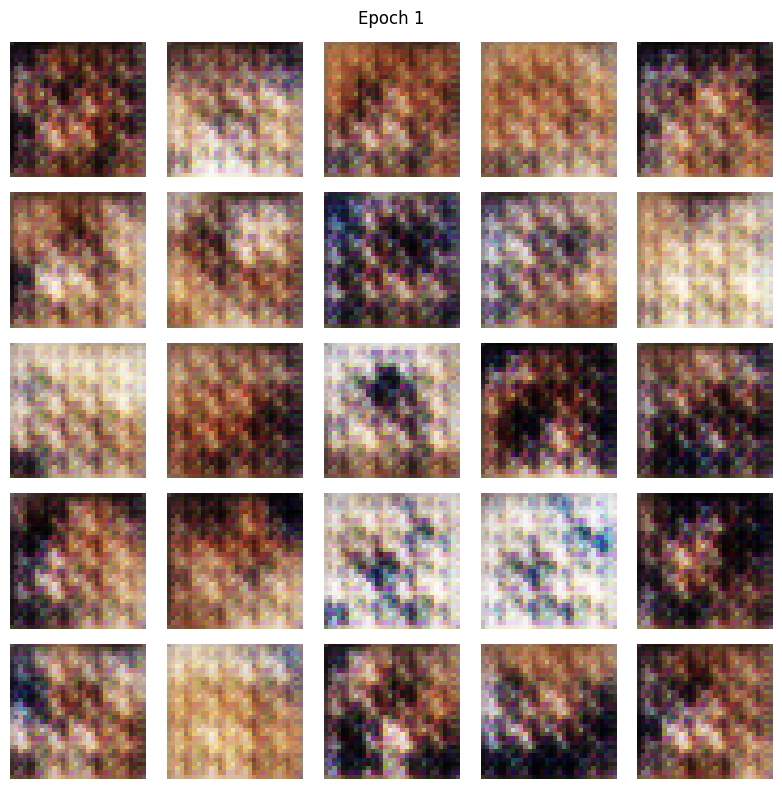

c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\genai-env\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 373.0799. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_001.pt
Epoch 01/80 | D loss: 1.7484 | G loss: -0.0173 | FID: 373.08


Epoch 2/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 02/80 | D loss: 1.9772 | G loss: 0.0646


Epoch 3/80:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 8/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 08/80 | D loss: 1.9946 | G loss: 0.0291


Epoch 9/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 09/80 | D loss: 1.9958 | G loss: 0.0174


Epoch 10/80:   0%|          | 0/391 [00:00<?, ?it/s]

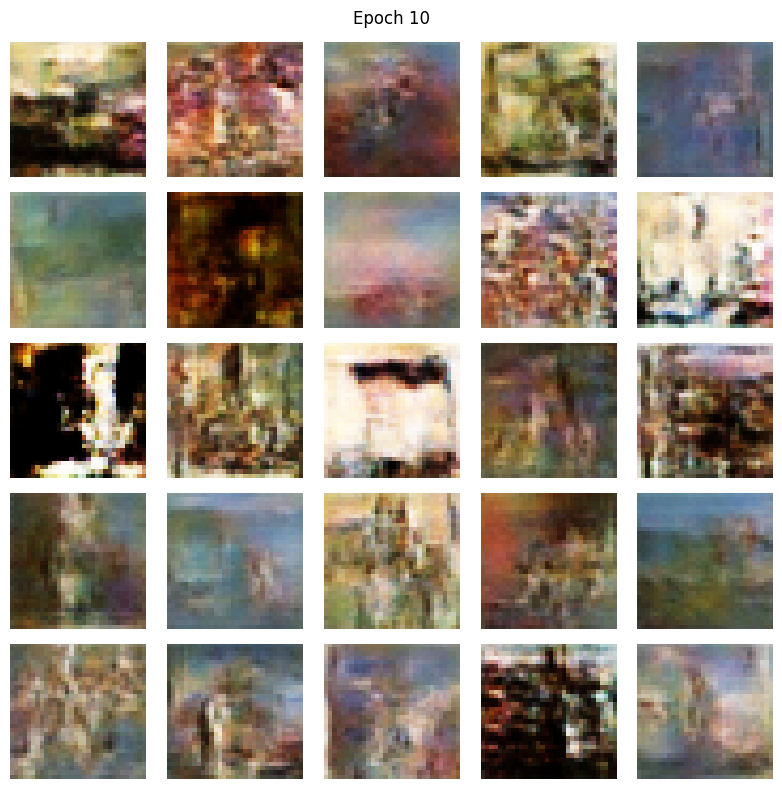

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 125.4613. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_010.pt
Epoch 10/80 | D loss: 1.9948 | G loss: 0.0133 | FID: 125.46


Epoch 11/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 11/80 | D loss: 1.9932 | G loss: 0.0114


Epoch 12/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 12/80 | D loss: 1.9924 | G loss: 0.0083


...

Epoch 18/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 18/80 | D loss: 1.9768 | G loss: 0.0169


Epoch 19/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 19/80 | D loss: 1.9545 | G loss: 0.0216


Epoch 20/80:   0%|          | 0/391 [00:00<?, ?it/s]

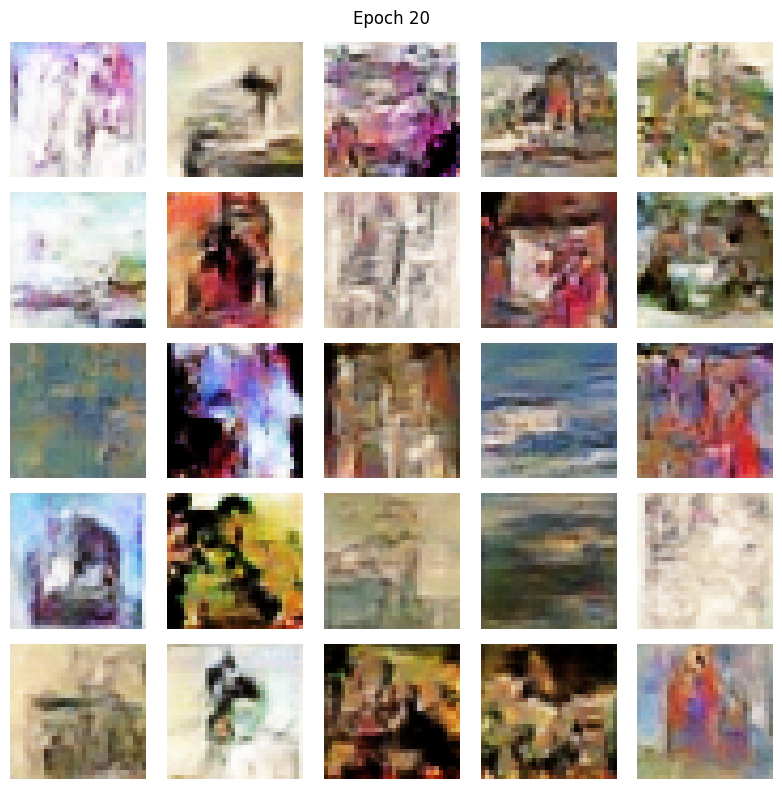

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 82.5082. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_020.pt
Epoch 20/80 | D loss: 1.9264 | G loss: 0.0201 | FID: 82.51


Epoch 21/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 21/80 | D loss: 1.9075 | G loss: 0.0145


Epoch 22/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 22/80 | D loss: 1.8925 | G loss: 0.0129


...

Epoch 28/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 28/80 | D loss: 1.8809 | G loss: -0.0013


Epoch 29/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 29/80 | D loss: 1.8846 | G loss: -0.0080


Epoch 30/80:   0%|          | 0/391 [00:00<?, ?it/s]

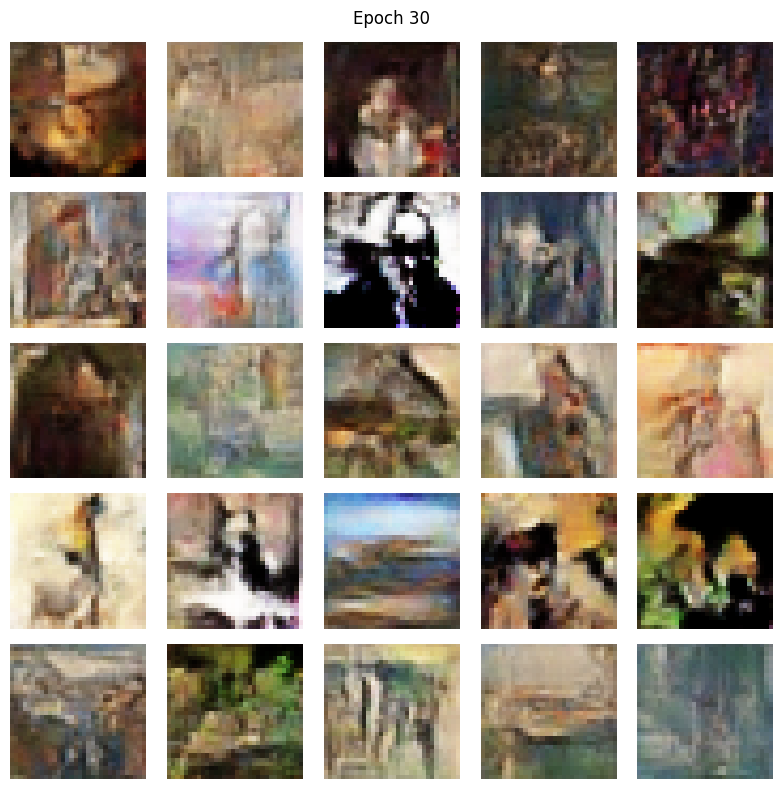

Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_030.pt
Epoch 30/80 | D loss: 1.8834 | G loss: -0.0043 | FID: 91.64


Epoch 31/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 31/80 | D loss: 1.8783 | G loss: -0.0107


Epoch 32/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 32/80 | D loss: 1.8771 | G loss: -0.0072


...

Epoch 38/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 38/80 | D loss: 1.8787 | G loss: -0.0143


Epoch 39/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 39/80 | D loss: 1.8812 | G loss: -0.0202


Epoch 40/80:   0%|          | 0/391 [00:00<?, ?it/s]

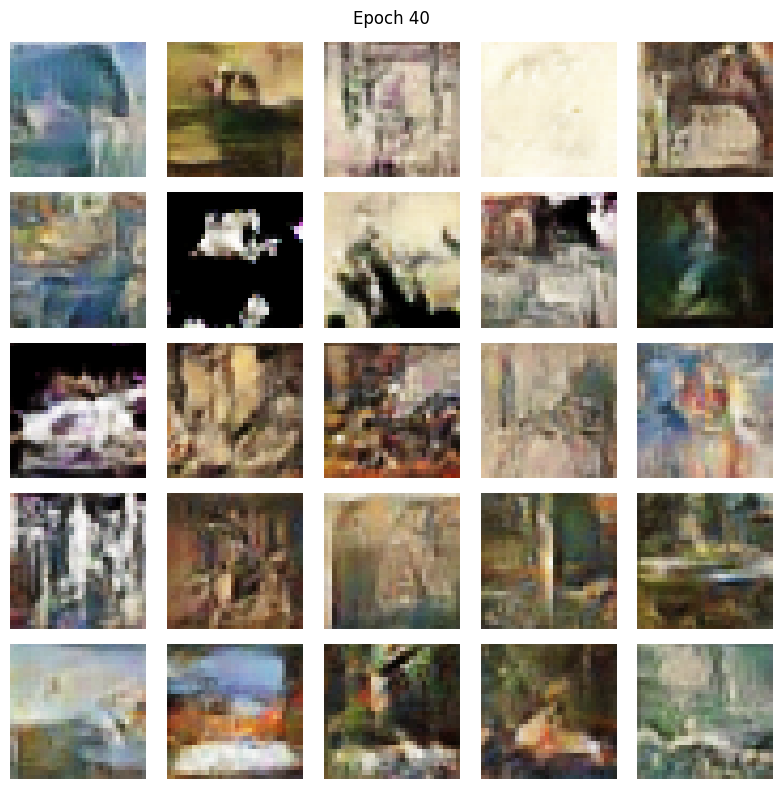

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 80.7159. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_040.pt
Epoch 40/80 | D loss: 1.8847 | G loss: -0.0174 | FID: 80.72


Epoch 41/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 41/80 | D loss: 1.8781 | G loss: -0.0189


Epoch 42/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 42/80 | D loss: 1.8850 | G loss: -0.0254


...

Epoch 48/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 48/80 | D loss: 1.8745 | G loss: -0.0359


Epoch 49/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 49/80 | D loss: 1.8836 | G loss: -0.0432


Epoch 50/80:   0%|          | 0/391 [00:00<?, ?it/s]

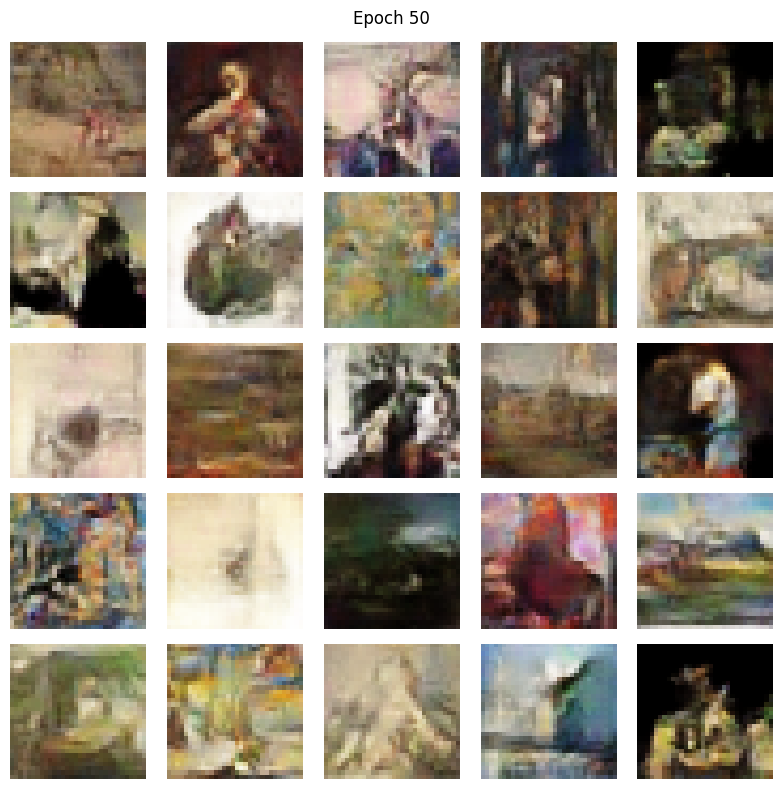

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 78.9089. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_050.pt
Epoch 50/80 | D loss: 1.8790 | G loss: -0.0363 | FID: 78.91


Epoch 51/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 51/80 | D loss: 1.8833 | G loss: -0.0422


Epoch 52/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 52/80 | D loss: 1.8750 | G loss: -0.0467


...

Epoch 58/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 58/80 | D loss: 1.8754 | G loss: -0.0634


Epoch 59/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 59/80 | D loss: 1.8812 | G loss: -0.0666


Epoch 60/80:   0%|          | 0/391 [00:00<?, ?it/s]

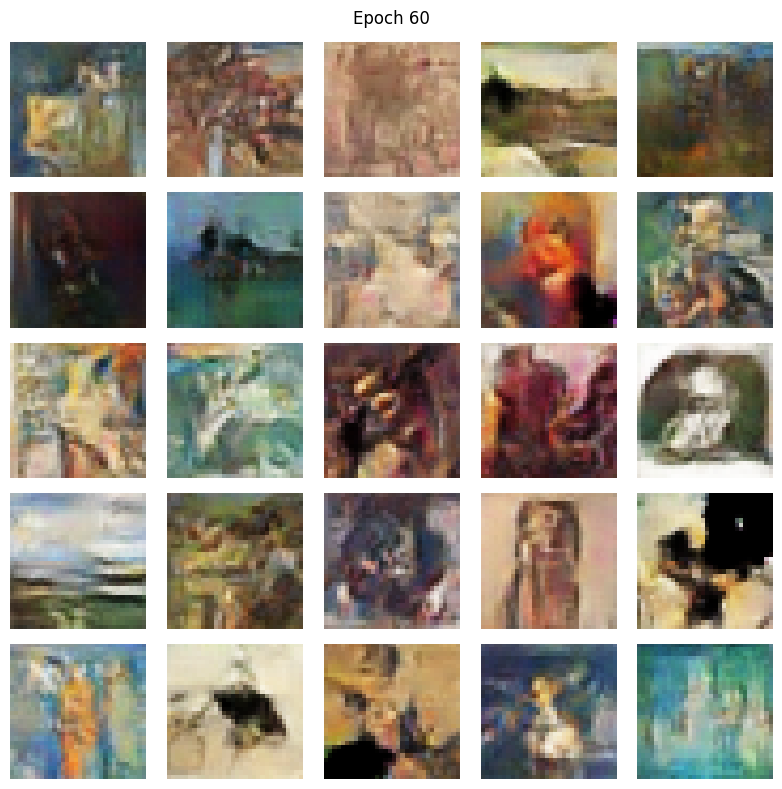

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 71.7857. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_060.pt
Epoch 60/80 | D loss: 1.8774 | G loss: -0.0681 | FID: 71.79


Epoch 61/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 61/80 | D loss: 1.8775 | G loss: -0.0646


Epoch 62/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 62/80 | D loss: 1.8771 | G loss: -0.0737


...

Epoch 68/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 68/80 | D loss: 1.8817 | G loss: -0.0759


Epoch 69/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 69/80 | D loss: 1.8762 | G loss: -0.0856


Epoch 70/80:   0%|          | 0/391 [00:00<?, ?it/s]

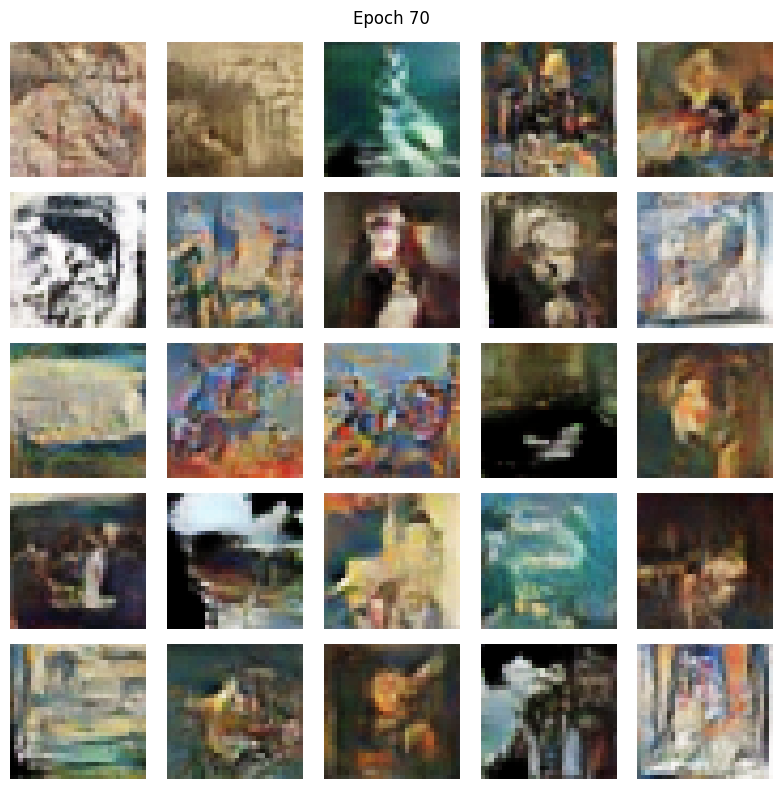

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 70.4013. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_070.pt
Epoch 70/80 | D loss: 1.8819 | G loss: -0.0795 | FID: 70.40


Epoch 71/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 71/80 | D loss: 1.8769 | G loss: -0.0930


Epoch 72/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 72/80 | D loss: 1.8755 | G loss: -0.0835


...

Epoch 78/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 78/80 | D loss: 1.8795 | G loss: -0.0910


Epoch 79/80:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 79/80 | D loss: 1.8763 | G loss: -0.0987


Epoch 80/80:   0%|          | 0/391 [00:00<?, ?it/s]

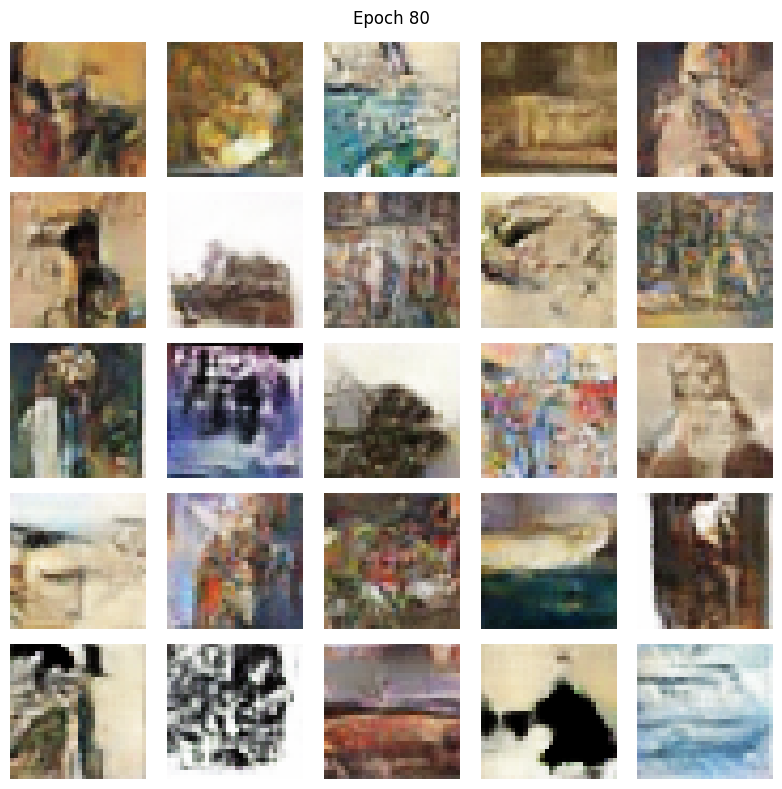

Saved checkpoint to runs\dcgan\final_run\best_fid_model.pt
   -> New best FID: 69.8835. Saved best_fid_model.pt
Saved checkpoint to runs\dcgan\final_run\checkpoint_epoch_080.pt
Epoch 80/80 | D loss: 1.8844 | G loss: -0.0930 | FID: 69.88


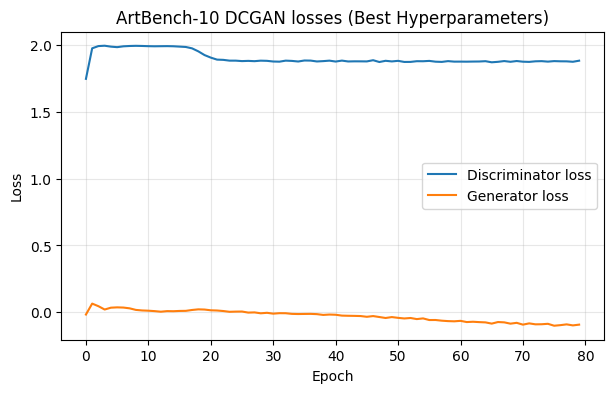

Saved checkpoint to runs\dcgan\artbench_dcgan_best_optuna.pt


In [ ]:
# Train with the best hyperparameters found by Optuna
# Uncomment line below to use Optuna results automatically:
#best_params = study.best_params




best_lr_g = 0.0004994872054273084
best_lr_d = 0.00035044090558002924
best_z_dim = 100
best_d_steps = 2
best_beta1 = 0.0
best_feature_maps = 64

best_generator = DCGenerator(
    latent_dim=best_z_dim, 
    image_channels=artbench_channels,
    ngf=best_feature_maps
).to(device)

best_discriminator = DCDiscriminator(
    image_channels=artbench_channels,
    ndf=best_feature_maps
).to(device)

best_generator.apply(init_dcgan_weights)
best_discriminator.apply(init_dcgan_weights)

# --- RE-LOAD FULL DATASET FOR FINAL TRAINING ---
print("Re-loading full ArtBench dataset (50k images)...")
artbench_train_loader_full, artbench_test_loader, _, _, _ = build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=None, # Use all 50k images
    data_root='IAGdata/artbench-10-python',
)

best_history, _ = train_gan(
    generator=best_generator,
    discriminator=best_discriminator,
    loader=artbench_train_loader_full,
    latent_dim=best_z_dim,
    epochs=80,
    lr_g=best_lr_g,
    lr_d=best_lr_d,
    d_steps=best_d_steps,
    beta1=best_beta1,
    beta2=0.99,
    print_progress=True,
    val_loader=artbench_test_loader,
    checkpoint_dir='runs/dcgan/final_run',
    save_interval=10
)

plot_gan_losses(best_history, title='ArtBench-10 DCGAN losses (Best Hyperparameters)')

# Salva o modelo treinado com os melhores hiperparâmetros
save_checkpoint(
    generator=best_generator,
    discriminator=best_discriminator,
    history=best_history,
    checkpoint_path='runs/dcgan/artbench_dcgan_best_optuna.pt',
    latent_dim=best_z_dim,
    channels=artbench_channels,
    image_size=artbench_image_size,
    feature_maps=best_feature_maps,
)

✅ Modelo campeão carregado com sucesso!
Gerando amostras aleatórias do espaço latente...


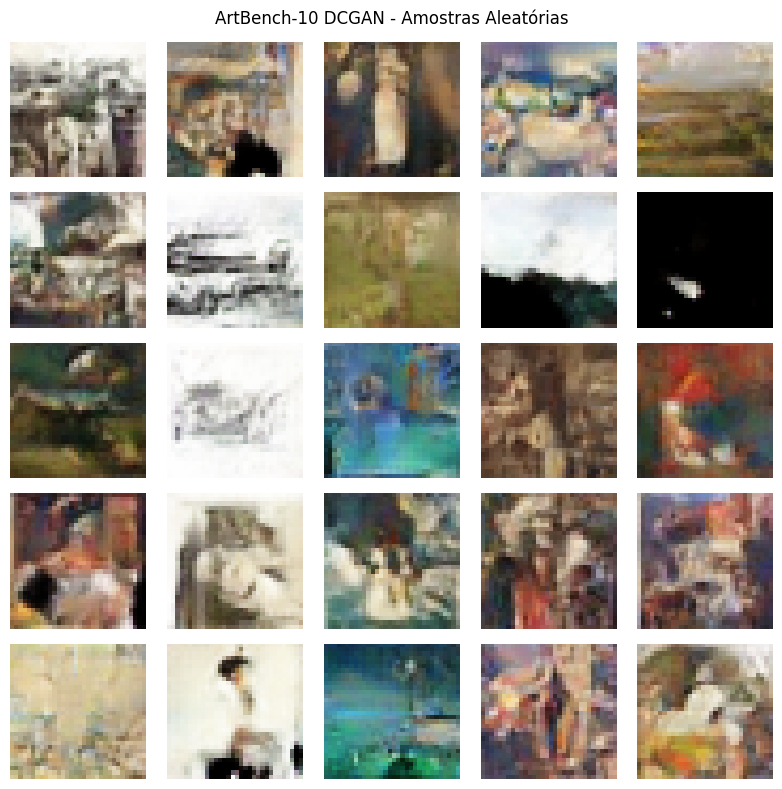


Caminhando suavemente pelo espaço latente...


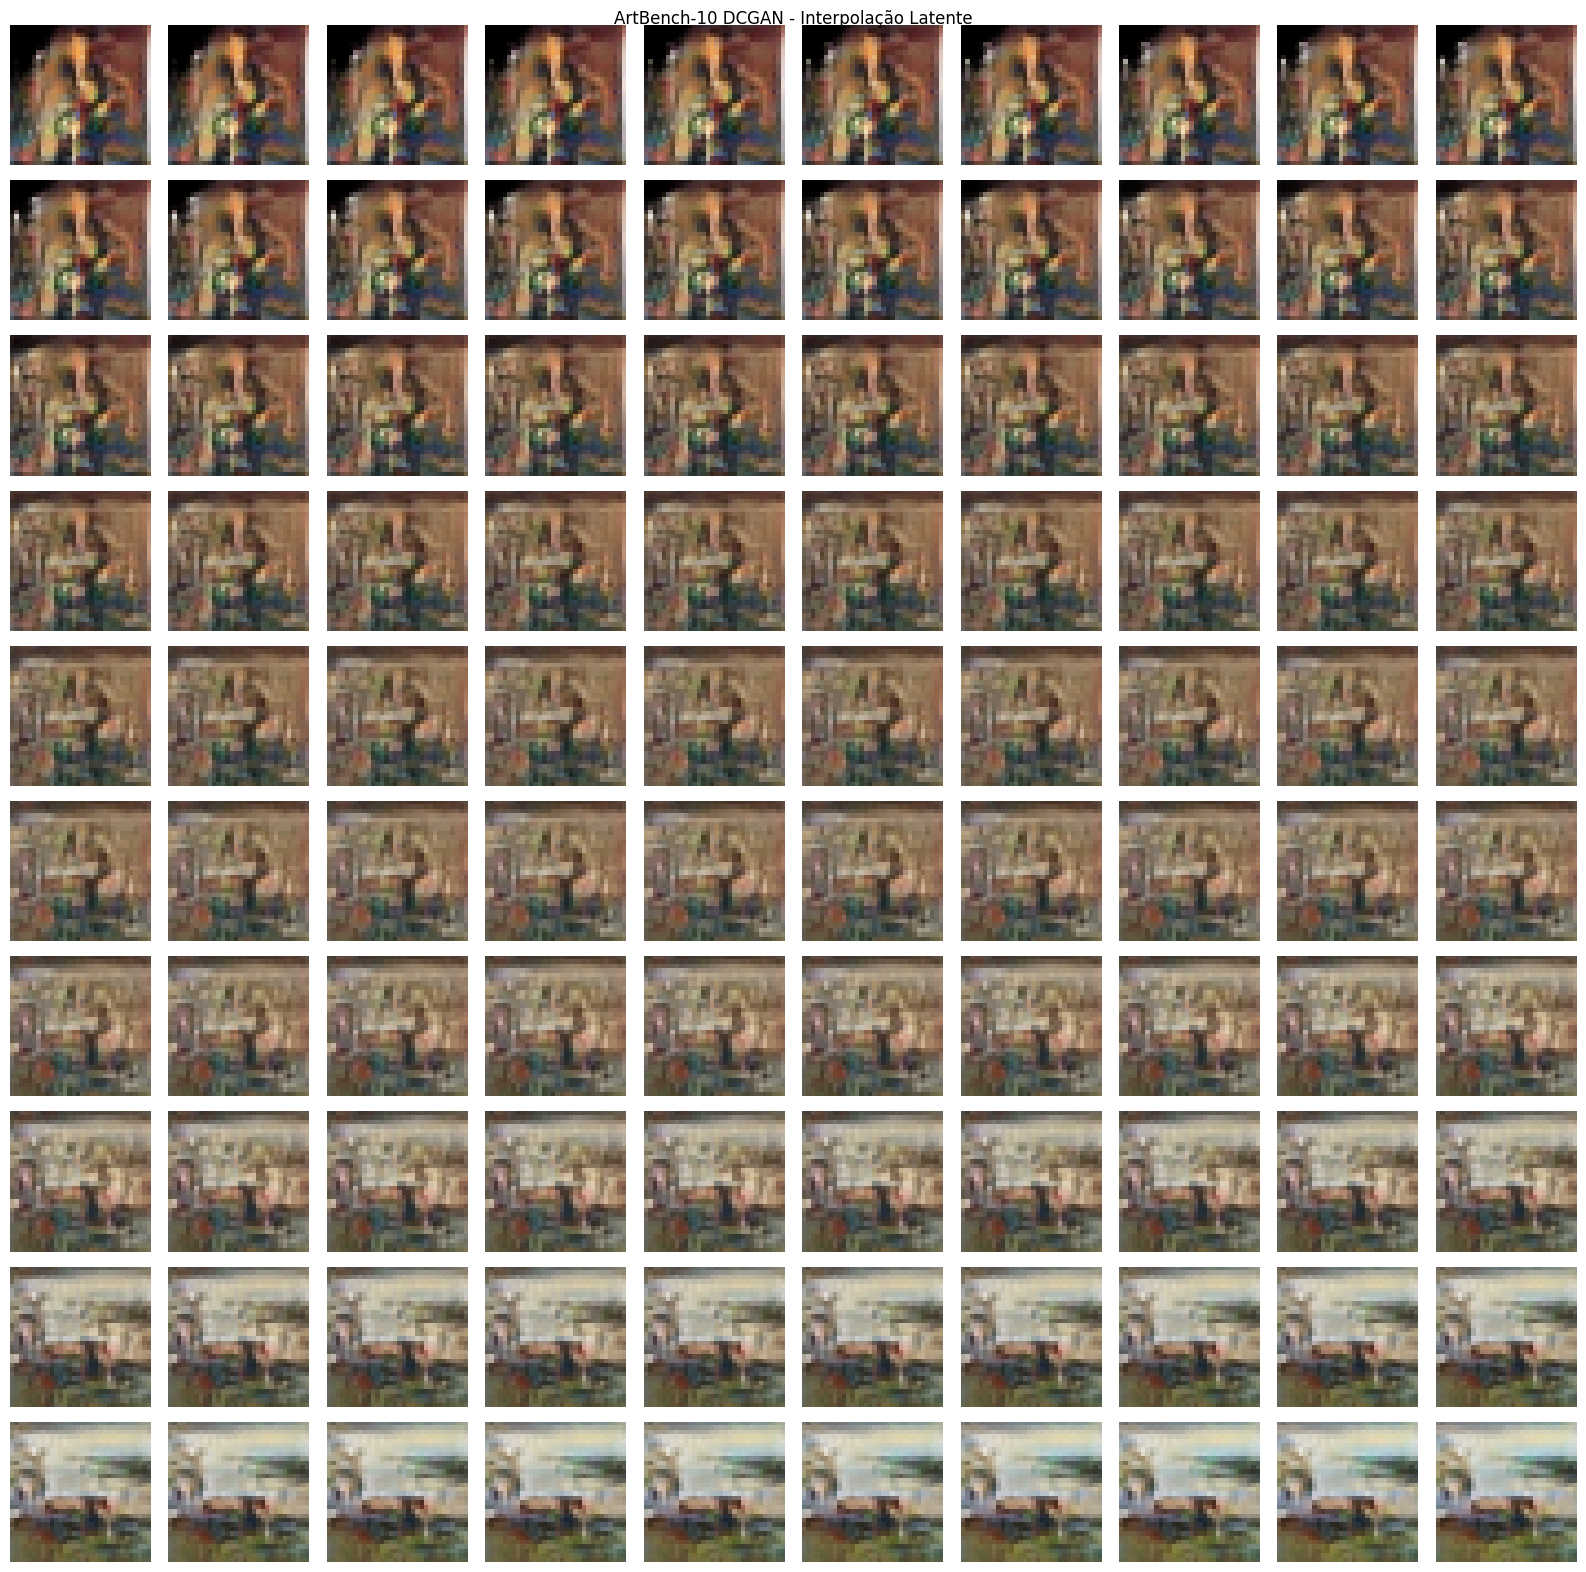

In [14]:
# ==========================================
# 1. CARREGANDO O MODELO TREINADO
# ==========================================
# Define o caminho exato do modelo campeão que acabamos de salvar
best_ckpt_path = Path('runs/dcgan/artbench_dcgan_best_optuna.pt')

# Usamos a função auxiliar para carregar o Gerador e suas configurações (cfg) do disco
if best_ckpt_path.exists():
    artbench_gen_infer, artbench_cfg, _ = load_dcgan_generator_for_inference(best_ckpt_path)
    print("✅ Modelo campeão carregado com sucesso!")
else:
    print(f" Checkpoint {best_ckpt_path} not found. Skipping inference.")
    artbench_gen_infer = None
    artbench_cfg = None

if artbench_gen_infer is not None and artbench_cfg is not None:
    # ==========================================
    # 2. EXECUTANDO A GERAÇÃO DE IMAGENS
    # ==========================================
    # TODO START
    print("Gerando amostras aleatórias do espaço latente...")
    # Extraímos os valores do dicionário de configuração (cfg) que foi salvo no checkpoint
    run_inference(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        n_samples=25,
        title='ArtBench-10 DCGAN - Amostras Aleatórias'
    )

    print("\nCaminhando suavemente pelo espaço latente...")
    latent_walk(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        steps=100, # Vai gerar 10 imagens mostrando a transição de uma obra para outra
        title='ArtBench-10 DCGAN - Interpolação Latente'
    )
    # TODO END

In [15]:
import requests, traceback

def notify(msg, title="Notebook"):
    requests.post("https://ntfy.sh/notebookIAGricardo",
        data=msg, headers={"Title": title, "Priority": "high"})

try:
    pass
    notify("✅ Finished successfully!")
except Exception as e:
    notify(f"❌ Failed: {traceback.format_exc()}", title="Notebook Error")

In [16]:
def run_robust_evaluation(generator, dataloader, latent_dim, device, num_runs=10):
    """
    Roda a avaliação múltiplas vezes com seeds diferentes para robustez estatística
    """
    fid_scores = []
    kid_means = []
    
    for i in range(num_runs):
        # Altera a seed a cada repetição 
        seed = 100 + i
        torch.manual_seed(seed)
        
        print(f"\n--- Iniciando Avaliação {i+1}/{num_runs} (Seed: {seed}) ---")
        
        fid_score, kid_mean, _ = evaluate_metrics(
            generator=generator, 
            dataloader=dataloader, 
            latent_dim=latent_dim, 
            device=device,
            num_samples=5000
        )
        
        fid_scores.append(fid_score)
        kid_means.append(kid_mean)
        print(f"Run {i+1} finalizada | FID: {fid_score:.4f} | KID (média): {kid_mean:.4f}")

    # Calcula Média e Desvio Padrão das 10 repetições
    final_fid_mean = np.mean(fid_scores)
    final_fid_std = np.std(fid_scores)
    final_kid_mean = np.mean(kid_means)
    final_kid_std = np.std(kid_means)

    print("\n" + "="*50)
    print("RESULTADOS FINAIS PARA O RELATÓRIO (10 Repetições):")
    print(f"FID: {final_fid_mean:.4f} ± {final_fid_std:.4f}")
    print(f"KID: {final_kid_mean:.4f} ± {final_kid_std:.4f}")
    print("="*50)

In [17]:
if artbench_gen_infer is not None and artbench_cfg is not None:
    print("\nIniciando Protocolo de Avaliação Quantitativa (Robustez Estatística)...")
    run_robust_evaluation(
        generator=artbench_gen_infer,
        dataloader=artbench_test_loader,  # Usar o loader de teste ou treino dependendo da escolha
        latent_dim=artbench_cfg['latent_dim'],
        device=device,
        num_runs=10 
    )


Iniciando Protocolo de Avaliação Quantitativa (Robustez Estatística)...

--- Iniciando Avaliação 1/10 (Seed: 100) ---
Run 1 finalizada | FID: 48.4596 | KID (média): 0.0277

--- Iniciando Avaliação 2/10 (Seed: 101) ---
Run 2 finalizada | FID: 47.9606 | KID (média): 0.0265

--- Iniciando Avaliação 3/10 (Seed: 102) ---
Run 3 finalizada | FID: 47.9533 | KID (média): 0.0252

--- Iniciando Avaliação 4/10 (Seed: 103) ---
Run 4 finalizada | FID: 48.0421 | KID (média): 0.0266

--- Iniciando Avaliação 5/10 (Seed: 104) ---
Run 5 finalizada | FID: 48.1078 | KID (média): 0.0273

--- Iniciando Avaliação 6/10 (Seed: 105) ---
Run 6 finalizada | FID: 48.4266 | KID (média): 0.0270

--- Iniciando Avaliação 7/10 (Seed: 106) ---
Run 7 finalizada | FID: 48.3043 | KID (média): 0.0269

--- Iniciando Avaliação 8/10 (Seed: 107) ---
Run 8 finalizada | FID: 48.2040 | KID (média): 0.0278

--- Iniciando Avaliação 9/10 (Seed: 108) ---
Run 9 finalizada | FID: 48.0903 | KID (média): 0.0275

--- Iniciando Avaliação 10

In [18]:
import requests, traceback

def notify(msg, title="Notebook"):
    requests.post("https://ntfy.sh/notebookIAGricardo",
        data=msg, headers={"Title": title, "Priority": "high"})

try:
    pass
    notify("✅ Finished successfully!")
except Exception as e:
    notify(f"❌ Failed: {traceback.format_exc()}", title="Notebook Error")

